# Mining massive data 
## Programming Assignment 1 (group 07)
### Locality Sensitive Hashing (LSH)



In [1]:
# Importing all necessary libraries
import os
import requests
import zipfile
import io
import pandas as pd
import numpy as np
import IPython.display as ipd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns
import time
np.random.seed(42)

### Data Preparation

In [2]:
# Settings 
url = "https://os.unil.cloud.switch.ch/fma/fma_metadata.zip"
zip_name = "fma_metadata.zip"

# Creating a folder
os.makedirs('cache', exist_ok=True)

# Check
if not os.path.exists(os.path.join('cache', 'fma_metadata/tracks.csv')):
    
    # Downloading file
    response = requests.get(url)
    
    if response.status_code == 200:
        # Unzipping
        with zipfile.ZipFile(io.BytesIO(response.content)) as f:
            f.extractall('cache')

In [3]:
# Downloading medium dataset
df_tracks = pd.read_csv('cache/fma_metadata/tracks.csv',index_col=0, header=[0, 1]) 
tracks_medium = df_tracks[df_tracks['set', 'subset'] == 'medium']

# Leaving only 8 genres
target_genres = ['Hip-Hop', 'Pop', 'Folk', 'Rock', 'Experimental', 'International', 'Electronic', 'Instrumental']
tracks = tracks_medium[tracks_medium['track', 'genre_top'].isin(target_genres)]

df_features = pd.read_csv('cache/fma_metadata/features.csv',index_col=0, header=[0, 1, 2]) 

In [4]:
common_ids = tracks.index.intersection(df_features.index)

X= df_features.loc[common_ids]  
y= tracks.loc[common_ids, ('track', 'genre_top')]

In [5]:
print("    Dataset Overview    ")
print(f"Total tracks:   {len(common_ids)}")
print(f"Features:       {X.shape[1]}")
print(f"\nGenre distribution:")
print(y.value_counts())
print(f"\nFeature statistics (before scaling):")
print(pd.DataFrame(X).describe().round(2))

    Dataset Overview    
Total tracks:   14942
Features:       518

Genre distribution:
(track, genre_top)
Rock             6103
Electronic       5314
Experimental     1251
Hip-Hop          1201
Folk              519
Instrumental      350
Pop               186
International      18
Name: count, dtype: int64

Feature statistics (before scaling):
feature    chroma_cens                                                    \
statistics    kurtosis                                                     
number              01        02        03        04        05        06   
count         14942.00  14942.00  14942.00  14942.00  14942.00  14942.00   
mean              0.23      0.14      0.30      0.19      0.16      0.23   
std               1.59      1.39      4.12      3.04      1.80      2.34   
min              -1.86     -1.91     -1.86     -1.87     -1.88     -1.91   
25%              -0.58     -0.62     -0.57     -0.60     -0.61     -0.56   
50%              -0.09     -0.15     -0.07   

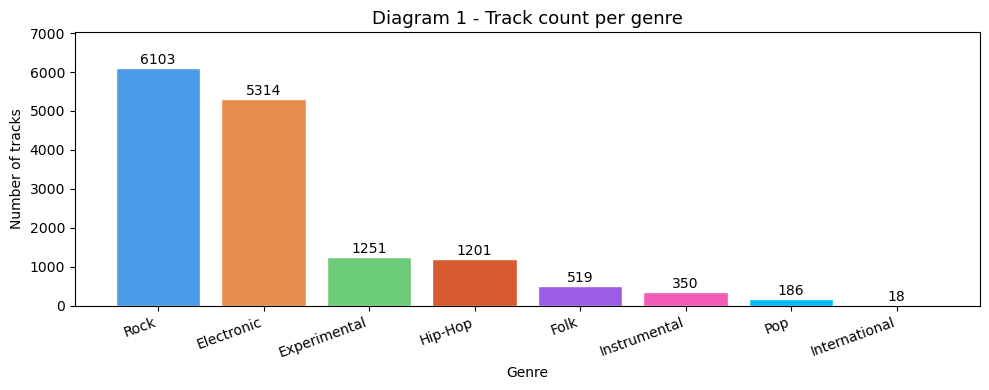

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))

counts = y.value_counts()
colors = ['#4C9BE8', '#E88C4C', '#6BCB77', '#D85A30',
          '#9B5DE5', '#F15BB5', '#00BBF9', '#FEE440']

bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white')

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            str(val), ha='center', va='bottom', fontsize=10)

ax.set_title('Diagram 1 - Track count per genre', fontsize=13)
ax.set_xlabel('Genre')
ax.set_ylabel('Number of tracks')
ax.set_ylim(0, counts.max() * 1.15)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('genre_distribution.png', dpi=150)
plt.show()

##### As we can see, the dataset is highly imbalanced. Rock accounts for 41% of all tracks, Electronic for 36%, and International for only 18 tracks (0.1%). This means that accuracy, as a metric, is somewhat misleading—the model might simply be guessing between Rock and Electronic and achieving a high score.

### Train/Validation/Test Splits

In [7]:
# Splitting data
split_info = tracks.loc[common_ids, ('set', 'split')]

X_train = X[split_info == 'training']
y_train = y[split_info == 'training']

X_val = X[split_info == 'validation']
y_val = y[split_info == 'validation']

X_test = X[split_info == 'test']
y_test = y[split_info == 'test']

print(f"Train: {X_train.shape} \nValidation: {X_val.shape} \nTest: {X_test.shape}")

Train: (11912, 518) 
Validation: (1495, 518) 
Test: (1535, 518)


##### The statistics for the features reveal significant differences in scale across all 518 features. For example, the zcr kurtosis index has a maximum value of 5,441, whereas the standard deviation of tonnetz is only 0.32. Without normalization, the Euclidean distance would be dominated by features with high values, effectively ignoring the rest. This necessitates the use of StandardScaler, which transforms each feature into a value with a mean of zero and a variance of one, ensuring that all features contribute equally to the distance calculation.

In [8]:
# Scaling the data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)


X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

### Construction of the Random Matrix

In [9]:
# Creating a function for Achlioptas matrix 
def achlioptas_matrix(d, l):
    vals = [np.sqrt(3), 0, -np.sqrt(3)]
    probs = [1/6, 2/3, 1/6]
    return np.random.choice(vals, size=(d, l), p=probs)

In [10]:
def generate_lsh_tables(X_train_scaled, n, l):
    d = X_train_scaled.shape[1] 
        
    lsh_tables = []
    r_matrices = []

    for i in range(n):
        R = achlioptas_matrix(d, l)
        r_matrices.append(R)
        table = {} 
        
        projections = np.dot(X_train_scaled, R)
        hashes = (projections >= 0).astype(int)
        
        for idx, h in enumerate(hashes):
            hash_tuple = tuple(h)
            if hash_tuple not in table:
                table[hash_tuple] = []
            table[hash_tuple].append(idx) 
        
        lsh_tables.append(table)
    return lsh_tables, r_matrices

In [11]:
def predict_genre(x, k, lsh_tables, r_matrices, X_train_scaled, y_train, metric='euclidean'):
    candidate_indices = set()
    for i in range(len(lsh_tables)):
        projection = np.dot(x, r_matrices[i])
        h = tuple((projection >= 0).astype(int))
        if h in lsh_tables[i]:
            candidate_indices.update(lsh_tables[i][h])

    if not candidate_indices:
        from collections import Counter
        return Counter(y_train).most_common(1)[0][0]

    candidate_list = list(candidate_indices)
    X_candidates = X_train_scaled[candidate_list]  # Matrix of candidates

    # Counting the similarity regarding the metrics 

    if metric == 'euclidean':
        # Euclidean distance
        distances = np.linalg.norm(X_candidates - x, axis=1)
        # Sorting in ascending order 
        sorted_indices = np.argsort(distances)[:k]

    elif metric == 'cosine':
        # Cosine similarity 
        norm_x = np.linalg.norm(x)
        norms_candidates = np.linalg.norm(X_candidates, axis=1)
        denominators = norm_x * norms_candidates
        denominators[denominators == 0] = 1e-10
        dot_products = X_candidates @ x

        similarities = dot_products / denominators
        # Sorting in descending order
        sorted_indices = np.argsort(similarities)[::-1][:k]

    # Majority vote 
    top_k_indices = [candidate_list[i] for i in sorted_indices]
    neighbor_genres = y_train.iloc[top_k_indices].values

    vote_counts = {}
    for genre in neighbor_genres:
        vote_counts[genre] = vote_counts.get(genre, 0) + 1
    
    most_common_genre = max(vote_counts, key=vote_counts.get)

    return most_common_genre

In [12]:
def evaluate_model(X_val_scaled, y_val, k, lsh_tables, r_matrices, X_train_scaled, y_train):
    predictions = []

    for track in X_val_scaled:
        res = predict_genre(track, k, lsh_tables, r_matrices, X_train_scaled, y_train)
        predictions.append(res)

    # Euclidean distance
    preds_euc = []
    for track in X_val_scaled:
        res = predict_genre(track, k, lsh_tables, r_matrices,
                            X_train_scaled, y_train, metric='euclidean')
        preds_euc.append(res)

    acc_euc = np.mean(np.array(preds_euc) == y_val.values)

    # Cosine similarity
    preds_cos = []
    for track in X_val_scaled:
        res = predict_genre(track, k, lsh_tables, r_matrices,
                            X_train_scaled, y_train, metric='cosine')
        preds_cos.append(res)

    acc_cos = np.mean(np.array(preds_cos) == y_val.values)
    return acc_euc, acc_cos

##### Cosine similarity measures the angle between two feature vectors, ignoring their magnitude. This is well-suited for audio features, where the shape of the feature profile matters more than the absolute values. Euclidean distance, on the other hand, is sensitive to the overall magnitude of the vectors. The observed difference between the two metrics is small (approximately 38 tracks out of 1,495) — this is partly because StandardScaler has already reduced magnitude differences, making the two metrics more similar in practice.

### Subtask 1

*We implemented LSH using the **random projection method** with the **Achlioptas matrix**. The algorithm works as follows: First, we construct a **random projection matrix** where each entry is √3, 0, or −√3 with probabilities 1/6, 2/3, and 1/6 respectively. This matrix takes a track's 518-dimensional feature vector and projects it down to a shorter vector of length **l**. Each projected value is then **binarized** — if it is ≥ 0 it becomes 1, otherwise 0 — producing a **binary hash code** for the track. All training tracks that share the same hash are placed into the same **bucket**. Since a single random projection can make mistakes — two similar tracks may end up with different hashes by chance — we repeat this process **n** times with different random matrices, creating **n independent hash tables**. If two tracks are similar, they are likely to land in the same bucket in at least one of the tables. When a new track arrives for classification, we compute its hash in each of the n tables and collect all training tracks that share a bucket with it in any table. Among these candidates, we compute the actual distance (**Euclidean** or **Cosine**), select the **k nearest neighbors**, and predict the genre by **majority vote**. If no candidates are found in any bucket, we fall back to predicting the **most common genre** in the training set.*

### General Training Algorithm and Hyperparameter Optimization

#### Trial and Error Way

In [13]:
# l = 10 - length of hash code
# n = 15 - hash tables
# k = 10 - number of nearest neighbors to consider for majority voting

for l in [5, 10, 15]:
    for n in [10, 15, 20]:
        for k in [5, 10, 15]:
            lsh_tables, r_matrices = generate_lsh_tables(X_train_scaled, n=n, l=l)

            acc_euc, acc_cos = evaluate_model(X_val_scaled, y_val, k=k, lsh_tables=lsh_tables, r_matrices=r_matrices, X_train_scaled=X_train_scaled, y_train=y_train)

            print(f"Parameters: l={l}, n={n}, k={k}")
            print(f"Euclidean distance:   {acc_euc * 100:.2f}%")
            print(f"Cosine similarity:  {acc_cos * 100:.2f}%\n")

Parameters: l=5, n=10, k=5
Euclidean distance:   67.29%
Cosine similarity:  69.36%

Parameters: l=5, n=10, k=10
Euclidean distance:   67.69%
Cosine similarity:  71.37%

Parameters: l=5, n=10, k=15
Euclidean distance:   68.83%
Cosine similarity:  71.97%

Parameters: l=5, n=15, k=5
Euclidean distance:   67.89%
Cosine similarity:  69.77%

Parameters: l=5, n=15, k=10
Euclidean distance:   69.16%
Cosine similarity:  71.17%

Parameters: l=5, n=15, k=15
Euclidean distance:   69.10%
Cosine similarity:  71.64%

Parameters: l=5, n=20, k=5
Euclidean distance:   67.63%
Cosine similarity:  69.70%

Parameters: l=5, n=20, k=10
Euclidean distance:   69.03%
Cosine similarity:  71.10%

Parameters: l=5, n=20, k=15
Euclidean distance:   68.96%
Cosine similarity:  71.37%

Parameters: l=10, n=10, k=5
Euclidean distance:   64.95%
Cosine similarity:  66.42%

Parameters: l=10, n=10, k=10
Euclidean distance:   66.96%
Cosine similarity:  70.17%

Parameters: l=10, n=10, k=15
Euclidean distance:   66.29%
Cosine si

In [14]:
# trying with some more values for l and n to see if we can get better results
for l in [5, 10]:
    for n in [20, 30, 40]:
        for k in [5, 10, 15]:
            lsh_tables, r_matrices = generate_lsh_tables(X_train_scaled, n=n, l=l)

            acc_euc, acc_cos = evaluate_model(X_val_scaled, y_val, k=k, lsh_tables=lsh_tables, r_matrices=r_matrices, X_train_scaled=X_train_scaled, y_train=y_train)

            print(f"Parameters: l={l}, n={n}, k={k}")
            print(f"Euclidean distance:   {acc_euc * 100:.2f}%")
            print(f"Cosine similarity:  {acc_cos * 100:.2f}%\n")

Parameters: l=5, n=20, k=5
Euclidean distance:   68.49%
Cosine similarity:  69.10%

Parameters: l=5, n=20, k=10
Euclidean distance:   68.96%
Cosine similarity:  71.77%

Parameters: l=5, n=20, k=15
Euclidean distance:   69.10%
Cosine similarity:  71.77%

Parameters: l=5, n=30, k=5
Euclidean distance:   68.36%
Cosine similarity:  68.96%

Parameters: l=5, n=30, k=10
Euclidean distance:   68.96%
Cosine similarity:  71.17%

Parameters: l=5, n=30, k=15
Euclidean distance:   69.16%
Cosine similarity:  71.64%

Parameters: l=5, n=40, k=5
Euclidean distance:   68.23%
Cosine similarity:  68.96%

Parameters: l=5, n=40, k=10
Euclidean distance:   69.23%
Cosine similarity:  71.30%

Parameters: l=5, n=40, k=15
Euclidean distance:   68.63%
Cosine similarity:  71.84%

Parameters: l=10, n=20, k=5
Euclidean distance:   67.22%
Cosine similarity:  68.70%

Parameters: l=10, n=20, k=10
Euclidean distance:   67.56%
Cosine similarity:  70.17%

Parameters: l=10, n=20, k=15
Euclidean distance:   68.03%
Cosine si

In [15]:
for l in [12]:
    for k in [11]:
        for n in [30]:
            lsh_tables, r_matrices = generate_lsh_tables(X_train_scaled, n=n, l=l)

            acc_euc, acc_cos = evaluate_model(X_val_scaled, y_val, k=k, lsh_tables=lsh_tables, r_matrices=r_matrices, X_train_scaled=X_train_scaled, y_train=y_train)

            print(f"Parameters: l={l}, n={n}, k={k}")
            print(f"Euclidean distance:   {acc_euc * 100:.2f}%")
            print(f"Cosine similarity:  {acc_cos * 100:.2f}%\n")

Parameters: l=12, n=30, k=11
Euclidean distance:   67.83%
Cosine similarity:  70.17%



#### A More Informed Way

##### If you try to run the above code, it may take about 30 minutes to run each of the first 2 cells. The functions from above recompute the distances and do the search for the hash tables each time the function is called. This part tries to optimize the functions from above. 

In [16]:
# the initial version of predict_genre() has a metric parameter to choose between euclidean and cosine similarity
# however, we can optimize it by calculating both metrics at once and returning the results together
# this way, we can speed things up in evaluate_model()

def get_genre_candidates(x, lsh_tables, r_matrices, X_train_scaled, y_train):
    candidate_indices = set()
    for i in range(len(lsh_tables)):
        projection = x @ r_matrices[i]
        h = tuple((projection >= 0).astype(int))
        if h in lsh_tables[i]:
            candidate_indices.update(lsh_tables[i][h])

    if not candidate_indices:
        return None, None

    candidate_list = list(candidate_indices)
    X_candidates = X_train_scaled[candidate_list]  # Matrix of candidates
    y_candidates = y_train.iloc[candidate_list].values

    # Euclidean distance
    distances = np.linalg.norm(X_candidates - x, axis=1)
    sorted_y_euc = y_candidates[np.argsort(distances)]
    
    # Cosine similarity 
    norm_x = np.linalg.norm(x)
    norms_candidates = np.linalg.norm(X_candidates, axis=1)
    sim_cos = (X_candidates @ x) / (norm_x * norms_candidates + 1e-10)
    sorted_y_cos = y_candidates[np.argsort(-sim_cos)]

    return sorted_y_euc, sorted_y_cos

In [17]:
# improved the evaluate_model() function to call get_genre_candidates() once per track
# and then calculate both metrics' predictions from the same candidate list
# this significantly reduces the number of calls to predict_genre() and speeds up the evaluation process
def evaluate_model_efficient(X_val_scaled, y_val, k_list, lsh_tables, r_matrices, X_train_scaled, y_train):
    # calculate global majority once to save time
    global_maj = y_train.mode()[0]
    accuracies = {k: {'euc': 0, 'cos': 0} for k in k_list}
    y_val_actual = y_val.values
    
    for i, track in enumerate(X_val_scaled):
        sorted_euc, sorted_cos = get_genre_candidates(track, lsh_tables, r_matrices, X_train_scaled, y_train)

        for k in k_list:
            if sorted_euc is None:
                p_euc, p_cos = global_maj, global_maj
            else:
                p_euc = Counter(sorted_euc[:k]).most_common(1)[0][0]
                p_cos = Counter(sorted_cos[:k]).most_common(1)[0][0]
            
            if p_euc == y_val_actual[i]: accuracies[k]['euc'] += 1
            if p_cos == y_val_actual[i]: accuracies[k]['cos'] += 1

    final_results = []
    for k in k_list:
        acc_euc = accuracies[k]['euc'] / len(y_val)
        acc_cos = accuracies[k]['cos'] / len(y_val)
        final_results.append((k, acc_euc, acc_cos))
    
    return final_results

#### Find Best Validation Accuracy

In [18]:
l_options = [10, 13, 15]
n_options = [20, 40, 60] 
k_options = [5, 11, 21]

best_acc = 0
best_params = {}
plot_data = []

for l in l_options:
    for n in n_options:
        lsh_tables, r_matrices = generate_lsh_tables(X_train_scaled, n=n, l=l)

        results = evaluate_model_efficient(X_val_scaled, y_val, k_options, 
                                           lsh_tables, r_matrices, 
                                           X_train_scaled, y_train)
        
        for k, acc_euc, acc_cos in results:
            if acc_euc > best_acc:
                best_acc = acc_euc
                best_params = {'l': l, 'n': n, 'k': k, 'metric': 'euclidean'}
            
            if acc_cos > best_acc:
                best_acc = acc_cos
                best_params = {'l': l, 'n': n, 'k': k, 'metric': 'cosine'}

            plot_data.append({'l': l, 'n': n, 'k': k, 'Accuracy' : acc_euc, 'Metric': 'Euclidean'})
            plot_data.append({'l': l, 'n': n, 'k': k, 'Accuracy' : acc_cos, 'Metric': 'Cosine'})

        # prints for debug
        # for k, acc_euc, acc_cos in results:
        #     print(f"Parameters: l={l}, n={n}, k={k}")
        #     print(f"Euclidean distance: {acc_euc * 100:.2f}%")
        #     print(f"Cosine similarity:  {acc_cos * 100:.2f}%\n")

print(f"Best Validation Accuracy: {best_acc*100:.2f}% with {best_params}")

Best Validation Accuracy: 72.24% with {'l': 10, 'n': 60, 'k': 21, 'metric': 'cosine'}


#### Run evaluation on test dataset

In [19]:
X_final_train = np.vstack((X_train_scaled, X_val_scaled))
y_final_train = pd.concat((y_train, y_val))

lsh_final_tables, r_final_matrices = generate_lsh_tables(X_final_train, n=best_params['n'], l=best_params['l'])

final_test_results = evaluate_model_efficient(X_test_scaled, y_test, [best_params['k']],
                                             lsh_final_tables, r_final_matrices, 
                                             X_final_train, y_final_train)

k, acc_euc, acc_cos = final_test_results[0]
final_test_acc = acc_euc if best_params['metric'] == 'euclidean' else acc_cos

print(f"--- FINAL TEST RESULTS ---")
print(f"Parameters: l={best_params['l']}, n={best_params['n']}, k={best_params['k']}")
print(f"Metric: {best_params['metric']}")
print(f"Final Accuracy on Test Set: {final_test_acc * 100:.2f}%")

--- FINAL TEST RESULTS ---
Parameters: l=10, n=60, k=21
Metric: cosine
Final Accuracy on Test Set: 70.03%


#### Some diagrams to show the best values for *l*, *n* and *k*

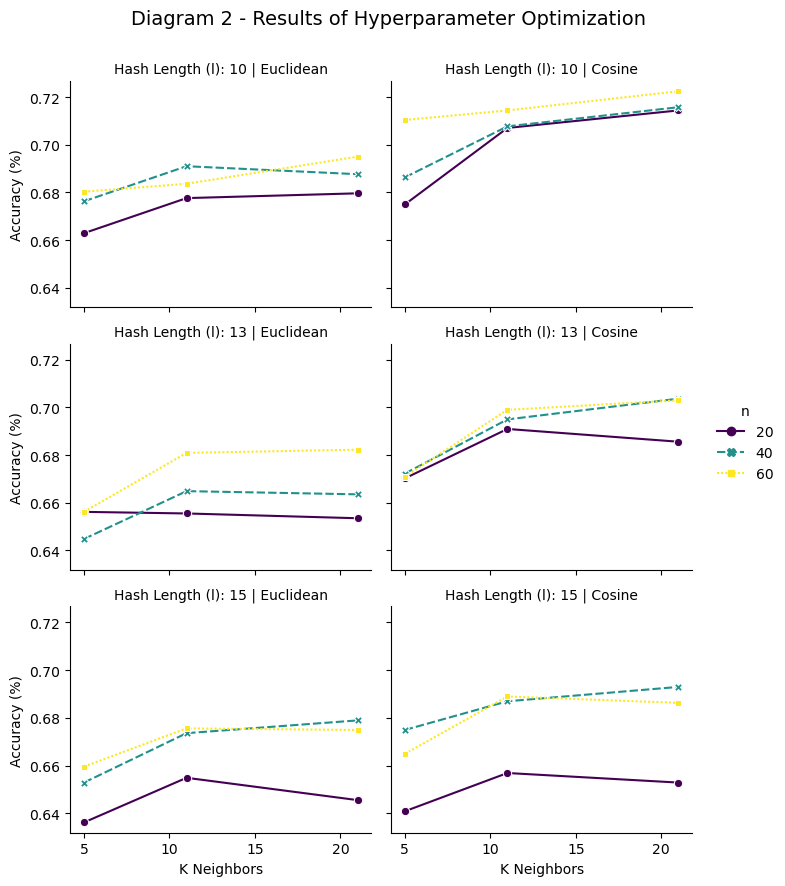

In [20]:
df_results = pd.DataFrame(plot_data)

def plot_lsh_results(df):
    g = sns.relplot(
        data=df,
        x="k", y="Accuracy",
        hue="n", style="n",
        col="Metric", row="l",
        kind="line", markers=True, palette="viridis",
        height=3, aspect=1.2
    )

    g.set_axis_labels("K Neighbors", "Accuracy (%)")
    g.set_titles("Hash Length (l): {row_name} | {col_name}")
    g.tight_layout()
    plt.subplots_adjust(top=0.9)
    g.figure.suptitle("Diagram 2 - Results of Hyperparameter Optimization", fontsize=14)
    
    plt.show()

plot_lsh_results(df_results)

In [21]:
# --- LSH timing ---
start = time.time()
for track in X_test_scaled:
    candidate_indices = set()
    for i in range(len(lsh_final_tables)):
        projection = track @ r_final_matrices[i]
        h = tuple((projection >= 0).astype(int))
        if h in lsh_final_tables[i]:
            candidate_indices.update(lsh_final_tables[i][h])
    if candidate_indices:
        candidate_list = list(candidate_indices)
        distances = np.linalg.norm(X_final_train[candidate_list] - track, axis=1)
        top_k = np.argsort(distances)[:best_params['k']]
lsh_time = time.time() - start

# --- Exact nearest neighbor search  ---
start = time.time()
for track in X_test_scaled:
    distances = np.linalg.norm(X_final_train - track, axis=1)
    top_k = np.argsort(distances)[:best_params['k']]
brute_time = time.time() - start

print(f"LSH search time:         {lsh_time:.2f}s")
print(f"Exact nearest neighbor search time: {brute_time:.2f}s")
print(f"Speedup:                 {brute_time / lsh_time:.1f}x")

LSH search time:         7.67s
Exact nearest neighbor search time: 24.42s
Speedup:                 3.2x


### Subtask 2

- The hyperparameter optimization was done using 3 different values for l, n and k. For the similarity measure, we used the Euclidean distance and the Cosine similarity. We tried every combination of the chosen values, and for every case, we computed the accuracy. The result of this experiment can be seen in diagram 2 from above.

- We settled on l=10, n=60, k=21, because the accuracy was the highest for these values. The cosine similarity was also chosen instead of Euclidean distance because it gave better accuracies for most of the combinations between l, n, and k.

- Our classification accuracy on the test set is 70.03%.

### Subtask 3
*__Achlioptas vs. Gaussian random projection:__
The advantage of the Achlioptas construction is that 2/3 of the matrix elements are zero. This makes the matrix **sparse**, which significantly speeds up matrix multiplication—multiplication by zero can be skipped entirely. Furthermore, the values are limited to just three options (√3, 0, −√3), so there is no need to generate resource-intensive Gaussian random numbers.*

*__How we handle music tracks for which fewer than k similar tracks are found:__
When a track has fewer than k similar candidates in its LSH cells, we simply use all available candidates for majority voting—that is, k is effectively reduced to the number of candidates found. If no candidates are found at all (the track does not share a cell with any training track in any of the n hash tables), we revert to predicting the **most common genre** in the training set as the baseline prediction.* 

*__Runtime of our approximate nearest neighbor algorithm in
comparison to that of an exact nearest neighbor search:__
LSH search time:         7.67s /
Exact nearest neighbor search time: 24.42s / 
Speedup:                 3.2x /   
Our LSH approach is roughly 3 times faster than the exact search. The speedup is moderate because our dataset is relatively small (~13,000 training tracks).*


### Subtask 4

- time spent on assignment + who did what: 
    - Bykova Polina: approx. 7 hours (Dataset overview, cosine similarity, report)
    - Shpilinska Stanislava: approx. 28 hours(Data preparation, data splitting, Euclidean distance, construction of random matrix)
    - Panainte Diana-Teodora: approx. 10 hours (Training algorithm, hyperparameters optimiztion, diagrams for optimization)